######  132_3_practical_lcm_timezone_answer.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [4]:
#cell 3
df = pd.read_csv("dataset/lcm_timezone_practice.csv",
                 encoding="utf-8-sig")
df

,defect_id,site,customer,model,defect_category,defect_qty,occ_at_utc,status,comment
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 00:15:00,回答済,日本時間の朝に確認
1,D002,WSE,Honda,310D,Coil,1,2026-07-01 05:30:00,回答済,午後発生として集計
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-01 14:10:00,回答済,日本時間では深夜帯
3,D004,META,Honda,J69P,Buck-IC,2,2026/07/02 15:40,調査中,スラッシュ区切り
4,D005,MEAX,Mitsubishi,310D,Coil,4,2026-07-02 23:20:00,回答済,日本時間では翌日
5,D006,MELAC,Honda,3BVT,NTF,1,2026-07-03 09:45:00,回答済,夕方発生
6,D007,SUS,Honda,36WA,Buck-IC,5,2026-07-03 12:30,回答済,分までの表記
7,D008,WSE,Mitsubishi,J69P,Coil,2,2026-07-04 02:10:00,調査中,午前発生
8,D009,GSE,Honda,310D,Coil,3,2026-07-04 22:55:00,回答済,翌朝発生
9,D010,META,Mitsubishi,36WA,Buck-IC,2,2026-07-05 06:30:00,回答済,午後発生


In [5]:
df.dtypes

defect_id          str
site               str
customer           str
model              str
defect_category    str
defect_qty         str
occ_at_utc         str
status             str
comment            str
dtype: object

In [6]:
df["defect_qty_num"] = pd.to_numeric(
    df["defect_qty"],
    errors="coerce",
)

df[
    [
        "defect_id",
        "defect_qty",
        "defect_qty_num",
    ]
]

,defect_id,defect_qty,defect_qty_num
0,D001,3,3.0
1,D002,1,1.0
2,D003,1,1.0
3,D004,2,2.0
4,D005,4,4.0
5,D006,1,1.0
6,D007,5,5.0
7,D008,2,2.0
8,D009,3,3.0
9,D010,2,2.0


In [7]:
df.dtypes

defect_id              str
site                   str
customer               str
model                  str
defect_category        str
defect_qty             str
occ_at_utc             str
status                 str
comment                str
defect_qty_num     float64
dtype: object

In [8]:
df["occ_at_utc_raw"] = df["occ_at_utc"]

df[
    [
        "defect_id",
        "occ_at_utc",
        "occ_at_utc_raw",
    ]
]

,defect_id,occ_at_utc,occ_at_utc_raw
0,D001,2026-07-01 00:15:00,2026-07-01 00:15:00
1,D002,2026-07-01 05:30:00,2026-07-01 05:30:00
2,D003,2026-07-01 14:10:00,2026-07-01 14:10:00
3,D004,2026/07/02 15:40,2026/07/02 15:40
4,D005,2026-07-02 23:20:00,2026-07-02 23:20:00
5,D006,2026-07-03 09:45:00,2026-07-03 09:45:00
6,D007,2026-07-03 12:30,2026-07-03 12:30
7,D008,2026-07-04 02:10:00,2026-07-04 02:10:00
8,D009,2026-07-04 22:55:00,2026-07-04 22:55:00
9,D010,2026-07-05 06:30:00,2026-07-05 06:30:00


In [11]:
df["occ_at_utc_clean"] = (
    df["occ_at_utc"]
    .astype("string")
    .str.strip()
)
df[
    [
        "defect_id",
        "occ_at_utc_raw",
        "occ_at_utc_clean",
    ]
]

,defect_id,occ_at_utc_raw,occ_at_utc_clean
0,D001,2026-07-01 00:15:00,2026-07-01 00:15:00
1,D002,2026-07-01 05:30:00,2026-07-01 05:30:00
2,D003,2026-07-01 14:10:00,2026-07-01 14:10:00
3,D004,2026/07/02 15:40,2026/07/02 15:40
4,D005,2026-07-02 23:20:00,2026-07-02 23:20:00
5,D006,2026-07-03 09:45:00,2026-07-03 09:45:00
6,D007,2026-07-03 12:30,2026-07-03 12:30
7,D008,2026-07-04 02:10:00,2026-07-04 02:10:00
8,D009,2026-07-04 22:55:00,2026-07-04 22:55:00
9,D010,2026-07-05 06:30:00,2026-07-05 06:30:00


In [12]:
df["occ_at_utc_dt"] = pd.to_datetime(
    df["occ_at_utc_clean"],
    format="mixed",
    errors="coerce",
)

df[
    [
        "defect_id",
        "occ_at_utc_clean",
        "occ_at_utc_dt",
    ]
]

,defect_id,occ_at_utc_clean,occ_at_utc_dt
0,D001,2026-07-01 00:15:00,2026-07-01 00:15:00
1,D002,2026-07-01 05:30:00,2026-07-01 05:30:00
2,D003,2026-07-01 14:10:00,2026-07-01 14:10:00
3,D004,2026/07/02 15:40,2026-07-02 15:40:00
4,D005,2026-07-02 23:20:00,2026-07-02 23:20:00
5,D006,2026-07-03 09:45:00,2026-07-03 09:45:00
6,D007,2026-07-03 12:30,2026-07-03 12:30:00
7,D008,2026-07-04 02:10:00,2026-07-04 02:10:00
8,D009,2026-07-04 22:55:00,2026-07-04 22:55:00
9,D010,2026-07-05 06:30:00,2026-07-05 06:30:00


In [13]:
df.dtypes

defect_id                      str
site                           str
customer                       str
model                          str
defect_category                str
defect_qty                     str
occ_at_utc                     str
status                         str
comment                        str
defect_qty_num             float64
occ_at_utc_raw                 str
occ_at_utc_clean            string
occ_at_utc_dt       datetime64[us]
dtype: object

In [14]:
df_date_ng = df[
    df["occ_at_utc_dt"].isna()
].copy()

df_date_ng[
    [
        "defect_id",
        "occ_at_utc_raw",
        "comment",
    ]
]

,defect_id,occ_at_utc_raw,comment
14,D015,NaN,発生日時が空欄
15,D016,2026-13-01 10:00:00,不正な月


In [15]:
df_qty_ng = df[
    df["defect_qty_num"].isna()
].copy()

df_qty_ng[
    [
        "defect_id",
        "defect_qty",
        "comment",
    ]
]

,defect_id,defect_qty,comment
17,D018,未入力,数量未入力


In [18]:
df["occ_at_jst"] = (
    df["occ_at_utc_dt"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Tokyo")
)

In [20]:
df[
    [
        "defect_id",
        "occ_at_utc_dt",
        "occ_at_jst",
    ]
].dtypes

defect_id                               str
occ_at_utc_dt                datetime64[us]
occ_at_jst       datetime64[us, Asia/Tokyo]
dtype: object

In [23]:
df_work = df[
    df["occ_at_utc_dt"].notna()
].copy()
df_work

,defect_id,site,customer,model,defect_category,defect_qty,occ_at_utc,status,comment,defect_qty_num,occ_at_utc_raw,occ_at_utc_clean,occ_at_utc_dt,occ_at_jst
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 00:15:00,回答済,日本時間の朝に確認,3.0,2026-07-01 00:15:00,2026-07-01 00:15:00,2026-07-01 00:15:00,2026-07-01 09:15:00+09:00
1,D002,WSE,Honda,310D,Coil,1,2026-07-01 05:30:00,回答済,午後発生として集計,1.0,2026-07-01 05:30:00,2026-07-01 05:30:00,2026-07-01 05:30:00,2026-07-01 14:30:00+09:00
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-01 14:10:00,回答済,日本時間では深夜帯,1.0,2026-07-01 14:10:00,2026-07-01 14:10:00,2026-07-01 14:10:00,2026-07-01 23:10:00+09:00
3,D004,META,Honda,J69P,Buck-IC,2,2026/07/02 15:40,調査中,スラッシュ区切り,2.0,2026/07/02 15:40,2026/07/02 15:40,2026-07-02 15:40:00,2026-07-03 00:40:00+09:00
4,D005,MEAX,Mitsubishi,310D,Coil,4,2026-07-02 23:20:00,回答済,日本時間では翌日,4.0,2026-07-02 23:20:00,2026-07-02 23:20:00,2026-07-02 23:20:00,2026-07-03 08:20:00+09:00
5,D006,MELAC,Honda,3BVT,NTF,1,2026-07-03 09:45:00,回答済,夕方発生,1.0,2026-07-03 09:45:00,2026-07-03 09:45:00,2026-07-03 09:45:00,2026-07-03 18:45:00+09:00
6,D007,SUS,Honda,36WA,Buck-IC,5,2026-07-03 12:30,回答済,分までの表記,5.0,2026-07-03 12:30,2026-07-03 12:30,2026-07-03 12:30:00,2026-07-03 21:30:00+09:00
7,D008,WSE,Mitsubishi,J69P,Coil,2,2026-07-04 02:10:00,調査中,午前発生,2.0,2026-07-04 02:10:00,2026-07-04 02:10:00,2026-07-04 02:10:00,2026-07-04 11:10:00+09:00
8,D009,GSE,Honda,310D,Coil,3,2026-07-04 22:55:00,回答済,翌朝発生,3.0,2026-07-04 22:55:00,2026-07-04 22:55:00,2026-07-04 22:55:00,2026-07-05 07:55:00+09:00
9,D010,META,Mitsubishi,36WA,Buck-IC,2,2026-07-05 06:30:00,回答済,午後発生,2.0,2026-07-05 06:30:00,2026-07-05 06:30:00,2026-07-05 06:30:00,2026-07-05 15:30:00+09:00


In [25]:
df_work["defect_qty_calc"] = (
    df_work["defect_qty_num"]
    .fillna(0)
    .astype(int)
)

df_work[
    [
        "defect_id",
        "defect_qty",
        "defect_qty_num",
        "defect_qty_calc",
    ]
]

,defect_id,defect_qty,defect_qty_num,defect_qty_calc
0,D001,3,3.0,3
1,D002,1,1.0,1
2,D003,1,1.0,1
3,D004,2,2.0,2
4,D005,4,4.0,4
5,D006,1,1.0,1
6,D007,5,5.0,5
7,D008,2,2.0,2
8,D009,3,3.0,3
9,D010,2,2.0,2


In [27]:
df_work["occ_date_jst"] = df_work["occ_at_jst"].dt.date

df_work[
    [
        "defect_id",
        "occ_at_jst",
        "occ_date_jst",
    ]
]

,defect_id,occ_at_jst,occ_date_jst
0,D001,2026-07-01 09:15:00+09:00,2026-07-01
1,D002,2026-07-01 14:30:00+09:00,2026-07-01
2,D003,2026-07-01 23:10:00+09:00,2026-07-01
3,D004,2026-07-03 00:40:00+09:00,2026-07-03
4,D005,2026-07-03 08:20:00+09:00,2026-07-03
5,D006,2026-07-03 18:45:00+09:00,2026-07-03
6,D007,2026-07-03 21:30:00+09:00,2026-07-03
7,D008,2026-07-04 11:10:00+09:00,2026-07-04
8,D009,2026-07-05 07:55:00+09:00,2026-07-05
9,D010,2026-07-05 15:30:00+09:00,2026-07-05


In [28]:
weekday_map = {
    0: "月曜日",
    1: "火曜日",
    2: "水曜日",
    3: "木曜日",
    4: "金曜日",
    5: "土曜日",
    6: "日曜日",
}

df_work["occ_weekday_jst"] = (
    df_work["occ_at_jst"]
    .dt.dayofweek
    .map(weekday_map)
)

df_work[
    [
        "defect_id",
        "occ_at_jst",
        "occ_weekday_jst",
    ]
]

,defect_id,occ_at_jst,occ_weekday_jst
0,D001,2026-07-01 09:15:00+09:00,水曜日
1,D002,2026-07-01 14:30:00+09:00,水曜日
2,D003,2026-07-01 23:10:00+09:00,水曜日
3,D004,2026-07-03 00:40:00+09:00,金曜日
4,D005,2026-07-03 08:20:00+09:00,金曜日
5,D006,2026-07-03 18:45:00+09:00,金曜日
6,D007,2026-07-03 21:30:00+09:00,金曜日
7,D008,2026-07-04 11:10:00+09:00,土曜日
8,D009,2026-07-05 07:55:00+09:00,日曜日
9,D010,2026-07-05 15:30:00+09:00,日曜日


In [29]:
#cell 16

df_work["occ_month_jst"] = df_work["occ_at_jst"].dt.strftime("%Y-%m")

df_work[
    [
        "defect_id",
        "occ_at_jst",
        "occ_month_jst",
    ]
]

,defect_id,occ_at_jst,occ_month_jst
0,D001,2026-07-01 09:15:00+09:00,2026-07
1,D002,2026-07-01 14:30:00+09:00,2026-07
2,D003,2026-07-01 23:10:00+09:00,2026-07
3,D004,2026-07-03 00:40:00+09:00,2026-07
4,D005,2026-07-03 08:20:00+09:00,2026-07
5,D006,2026-07-03 18:45:00+09:00,2026-07
6,D007,2026-07-03 21:30:00+09:00,2026-07
7,D008,2026-07-04 11:10:00+09:00,2026-07
8,D009,2026-07-05 07:55:00+09:00,2026-07
9,D010,2026-07-05 15:30:00+09:00,2026-07


In [30]:
df_work["occ_hour_jst"] = df_work["occ_at_jst"].dt.hour

df_work[
    [
        "defect_id",
        "occ_at_jst",
        "occ_hour_jst",
    ]
]

,defect_id,occ_at_jst,occ_hour_jst
0,D001,2026-07-01 09:15:00+09:00,9
1,D002,2026-07-01 14:30:00+09:00,14
2,D003,2026-07-01 23:10:00+09:00,23
3,D004,2026-07-03 00:40:00+09:00,0
4,D005,2026-07-03 08:20:00+09:00,8
5,D006,2026-07-03 18:45:00+09:00,18
6,D007,2026-07-03 21:30:00+09:00,21
7,D008,2026-07-04 11:10:00+09:00,11
8,D009,2026-07-05 07:55:00+09:00,7
9,D010,2026-07-05 15:30:00+09:00,15


In [31]:
df_work["occ_time_zone_jst"] = ""

df_work.loc[
    df_work["occ_hour_jst"].between(0, 5),
    "occ_time_zone_jst"
] = "深夜"

df_work.loc[
    df_work["occ_hour_jst"].between(6, 11),
    "occ_time_zone_jst"
] = "午前"

df_work.loc[
    df_work["occ_hour_jst"].between(12, 17),
    "occ_time_zone_jst"
] = "午後"

df_work.loc[
    df_work["occ_hour_jst"].between(18, 23),
    "occ_time_zone_jst"
] = "夜間"

df_work[
    [
        "defect_id",
        "occ_hour_jst",
        "occ_time_zone_jst",
    ]
]


,defect_id,occ_hour_jst,occ_time_zone_jst
0,D001,9,午前
1,D002,14,午後
2,D003,23,夜間
3,D004,0,深夜
4,D005,8,午前
5,D006,18,夜間
6,D007,21,夜間
7,D008,11,午前
8,D009,7,午前
9,D010,15,午後


In [33]:
df_weekday_summary = df_work.groupby(
    "occ_weekday_jst",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)

df_weekday_summary

,occ_weekday_jst,defect_count,defect_qty_sum
0,土曜日,1,2
1,日曜日,3,6
2,月曜日,1,1
3,木曜日,1,0
4,水曜日,4,5
5,火曜日,2,6
6,金曜日,4,12


In [34]:
weekday_order = [
    "月曜日",
    "火曜日",
    "水曜日",
    "木曜日",
    "金曜日",
    "土曜日",
    "日曜日",
]

df_weekday_summary["weekday_order"] = pd.Categorical(
    df_weekday_summary["occ_weekday_jst"],
    categories=weekday_order,
    ordered=True,
)



In [35]:
df_weekday_summary = df_weekday_summary.sort_values(
    "weekday_order",
).drop(
    columns="weekday_order",
).reset_index(
    drop=True,
)

df_weekday_summary

,occ_weekday_jst,defect_count,defect_qty_sum
0,月曜日,1,1
1,火曜日,2,6
2,水曜日,4,5
3,木曜日,1,0
4,金曜日,4,12
5,土曜日,1,2
6,日曜日,3,6


In [36]:
df_time_zone_summary = df_work.groupby(
    "occ_time_zone_jst",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)

df_time_zone_summary

,occ_time_zone_jst,defect_count,defect_qty_sum
0,午前,5,13
1,午後,3,7
2,夜間,5,8
3,深夜,3,4


In [37]:
time_zone_order = [
    "深夜",
    "午前",
    "午後",
    "夜間"
]

df_time_zone_summary["time_zone_order"] = pd.Categorical(
    df_time_zone_summary["occ_time_zone_jst"],
    categories=time_zone_order,
    ordered=True,
)

In [38]:
df_time_zone_summary = df_time_zone_summary.sort_values(
    "time_zone_order",
).drop(
    columns="time_zone_order",
).reset_index(
    drop=True,
)

df_time_zone_summary

,occ_time_zone_jst,defect_count,defect_qty_sum
0,深夜,3,4
1,午前,5,13
2,午後,3,7
3,夜間,5,8


In [39]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

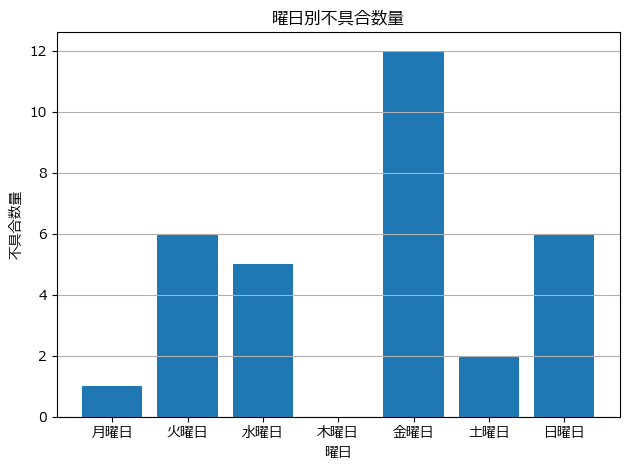

In [46]:
plt.bar(
    df_weekday_summary["occ_weekday_jst"],
    df_weekday_summary["defect_qty_sum"],
)

plt.title("曜日別不具合数量")
plt.xlabel("曜日")
plt.ylabel("不具合数量")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [47]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

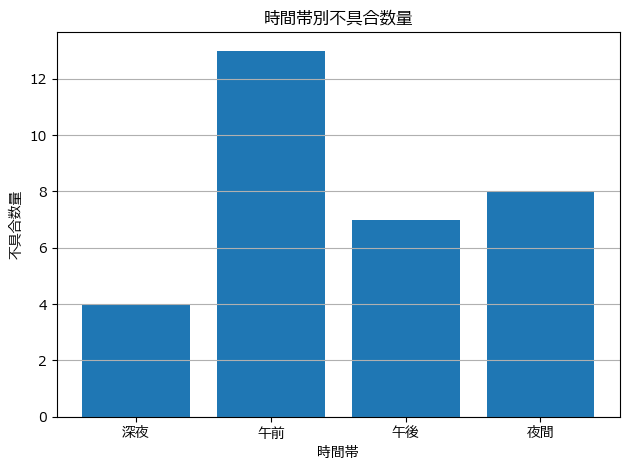

In [56]:
plt.bar(
    df_time_zone_summary["occ_time_zone_jst"],
    df_time_zone_summary["defect_qty_sum"],
)

plt.title("時間帯別不具合数量")
plt.xlabel("時間帯")
plt.ylabel("不具合数量")

plt.grid(axis="y")
plt.tight_layout()

plt.show()